## Data Cleaning and Saving

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/ChitwanDataset.xls', engine='xlrd')

In [ ]:
import os
import pandas as pd

# Define the path to your cleaned clustering file
cleaned_cluster_path = '/content/drive/MyDrive/chitwan_clustering.csv'

if os.path.exists(cleaned_cluster_path):
    print("Cleaned clustering dataset found. Loading from Drive...")
    df_cluster = pd.read_csv(cleaned_cluster_path)
else:
    print("Cleaned dataset not found.")

print(f"Dataset Ready for DBSCAN: {df_cluster.shape[0]} records.")

Cleaned clustering dataset found. Loading from Drive...
Dataset Ready for DBSCAN: 778 records.


In [ ]:
# Keeping only necessary columns
# Easting/Northing are the core clustering features, PROBLEM_ANIMAL and CONFLICT_TYPE will help us interpret and label the clusters afterward
df_cluster = df[['Easting', 'Northing', 'PROBLEM_ANIMAL', 'CONFLICT_TYPE']]

In [ ]:
df_cluster = df.copy()

# Select columns
df_cluster = df_cluster[['Easting', 'Northing', 'PROBLEM_ANIMAL', 'CONFLICT_TYPE']]

# Drop missing coordinates since clustering is entirely coordinate based
df_cluster = df_cluster.dropna(subset=['Easting', 'Northing'])

In [ ]:
# Standardize categorical columns
df_cluster['PROBLEM_ANIMAL'] = df_cluster['PROBLEM_ANIMAL'].str.strip().str.title()
df_cluster['CONFLICT_TYPE'] = df_cluster['CONFLICT_TYPE'].str.strip().str.title()

In [ ]:
# Remove duplicates
df_cluster = df_cluster.drop_duplicates()

In [ ]:
# Verify
print(df_cluster.isnull().sum())
print(df_cluster.shape)

Easting           0
Northing          0
PROBLEM_ANIMAL    0
CONFLICT_TYPE     0
dtype: int64
(778, 4)


In [ ]:
# Save
df_cluster.to_csv('/content/drive/MyDrive/chitwan_clustering.csv', index=False)

## EDA Visualization

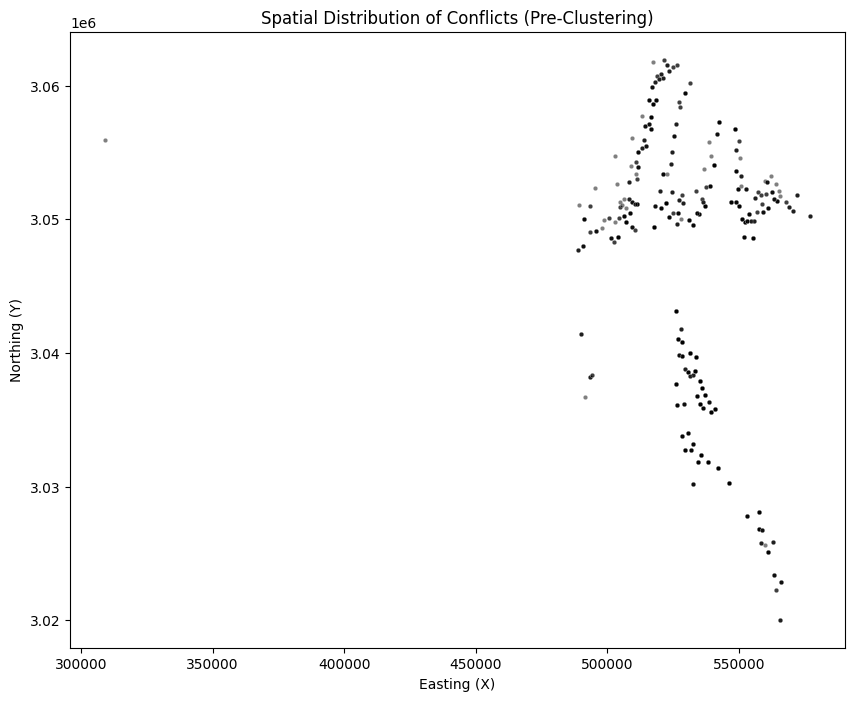

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_cluster, x='Easting', y='Northing', alpha=0.5, s=10, color='black')
plt.title('Spatial Distribution of Conflicts (Pre-Clustering)')
plt.xlabel('Easting (X)')
plt.ylabel('Northing (Y)')
plt.show()

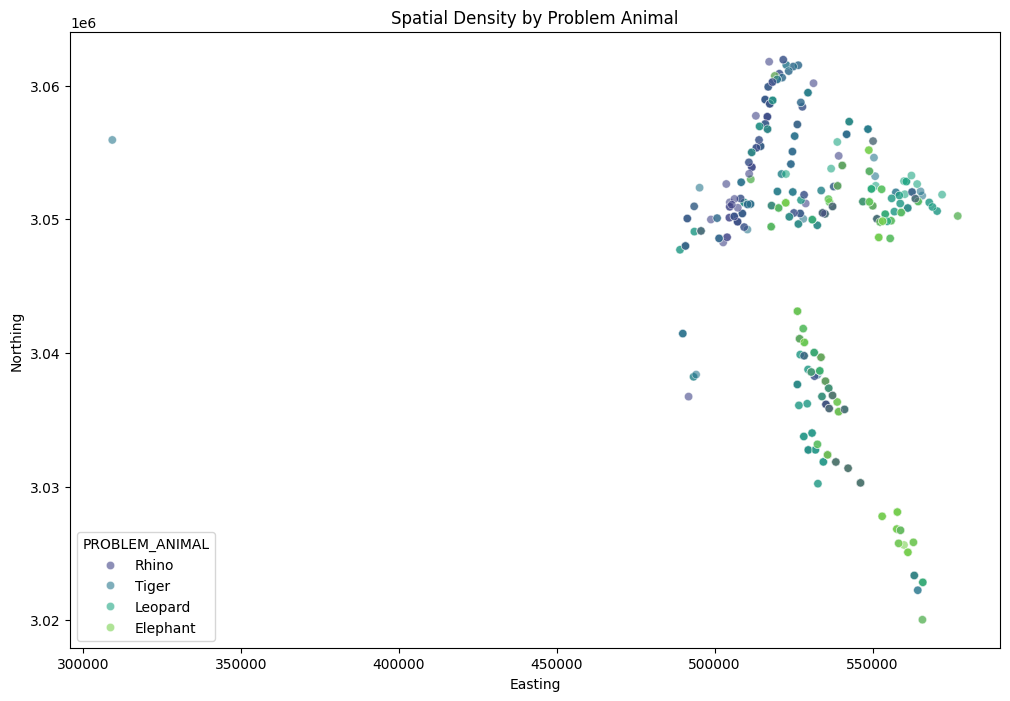

In [ ]:
plt.figure(figsize=(12, 8))
# Filtering for the top 3-4 problem animals for clarity
top_animals = df_cluster['PROBLEM_ANIMAL'].value_counts().nlargest(4).index
sns.scatterplot(data=df_cluster[df_cluster['PROBLEM_ANIMAL'].isin(top_animals)],
                x='Easting', y='Northing', hue='PROBLEM_ANIMAL', palette='viridis', alpha=0.6)
plt.title('Spatial Density by Problem Animal')
plt.show()

## DBSCAN Clustering

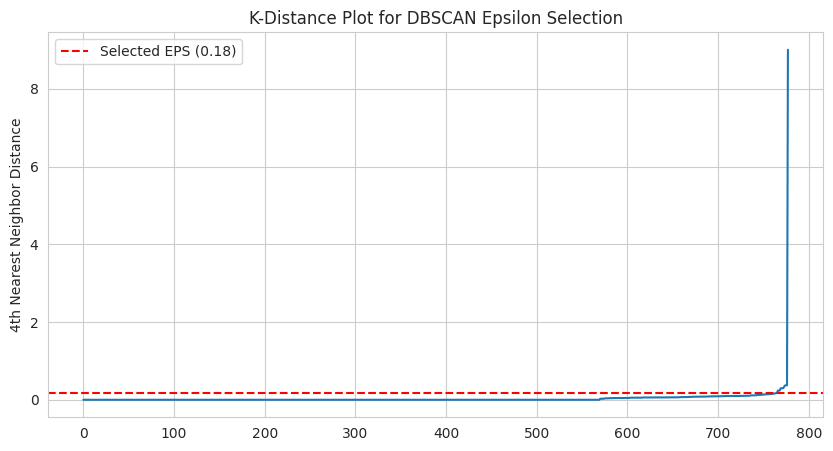

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# FIND OPTIMIZED EPSILON
# DBSCAN needs a distance threshold (eps). We find the "elbow" where density drops.
coords = df_cluster[['Easting', 'Northing']]
scaler_std = StandardScaler()
coords_scaled = scaler_std.fit_transform(coords)

neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(coords_scaled)
distances, indices = nbrs.kneighbors(coords_scaled)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Plot for DBSCAN Epsilon Selection')
plt.ylabel('4th Nearest Neighbor Distance')
plt.axhline(y=0.18, color='r', linestyle='--', label='Selected EPS (0.18)')
plt.legend()
plt.show()

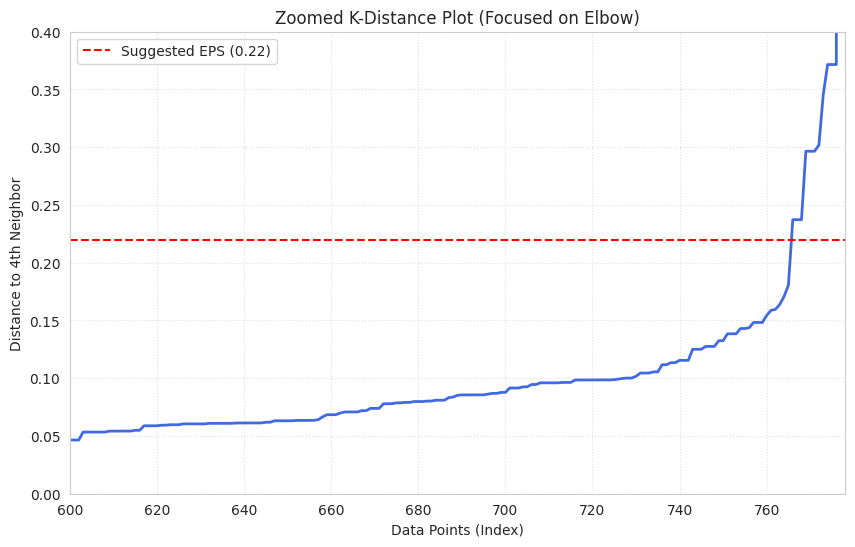

In [ ]:
# --- ZOOMED IN ELBOW PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2, color='royalblue')

# Zooming in on the Y-axis (Distances) and X-axis (The last 200 points)
plt.ylim(0, 0.4)    # Focus only on the 0.0 to 0.4 range
plt.xlim(600, 778)  # Focus only on the points where the curve starts

# Adding the suggested threshold line
plt.axhline(y=0.22, color='r', linestyle='--', label='Suggested EPS (0.22)')

plt.title('Zoomed K-Distance Plot (Focused on Elbow)')
plt.xlabel('Data Points (Index)')
plt.ylabel('Distance to 4th Neighbor')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# --- STEP 2: RUN DBSCAN ---
# We use eps=0.22 based on the elbow plot
dbscan = DBSCAN(eps=0.22, min_samples=10)
df_cluster['DBSCAN_Cluster'] = dbscan.fit_predict(coords_scaled)

In [ ]:
# --- STEP 3: VALIDATION ---
# Silhouette score only works for non-noise points (Label != -1)[cite: 860, 861].
mask = df_cluster['DBSCAN_Cluster'] != -1
if len(df_cluster['DBSCAN_Cluster'][mask].unique()) > 1:
    db_score = silhouette_score(coords_scaled[mask], df_cluster['DBSCAN_Cluster'][mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {db_score:.3f}")

DBSCAN Silhouette Score (excluding noise): 0.453


In [ ]:
# --- STEP 4: STRATEGIC INTERPRETATION (DBSCAN) ---
# Now we look at the clusters that achieved the 0.45 score.

# Filter out noise (-1) to focus on the identified hotspots
hotspots = df_cluster[df_cluster['DBSCAN_Cluster'] != -1]

db_report = hotspots.groupby('DBSCAN_Cluster').agg({
    'PROBLEM_ANIMAL': lambda x: x.mode()[0] if not x.mode().empty else "Mixed",
    'CONFLICT_TYPE': lambda x: x.mode()[0] if not x.mode().empty else "Mixed",
    'Easting': 'count'
}).rename(columns={'Easting': 'Incident_Count', 'PROBLEM_ANIMAL': 'Primary_Animal'})

# Calculate Priority
db_report['Priority_Level'] = db_report['Incident_Count'].apply(
    lambda x: 'CRITICAL' if x > db_report['Incident_Count'].quantile(0.75) else 'ACTIVE'
)

print("\n--- FINAL DBSCAN HOTSPOT ANALYSIS---")
print(db_report.sort_values(by='Incident_Count', ascending=False))


--- FINAL DBSCAN HOTSPOT ANALYSIS---
               Primary_Animal          CONFLICT_TYPE  Incident_Count  \
DBSCAN_Cluster                                                         
0                       Rhino       Attacks To Human             182   
4                    Elephant  Livestock Depredation             167   
1                       Tiger       Attacks To Human             150   
3                     Leopard  Livestock Depredation             143   
5                       Tiger  Livestock Depredation              65   
2                    Elephant       Attacks To Human              39   
6                    Elephant       Attacks To Human              10   

               Priority_Level  
DBSCAN_Cluster                 
0                    CRITICAL  
4                    CRITICAL  
1                      ACTIVE  
3                      ACTIVE  
5                      ACTIVE  
2                      ACTIVE  
6                      ACTIVE  


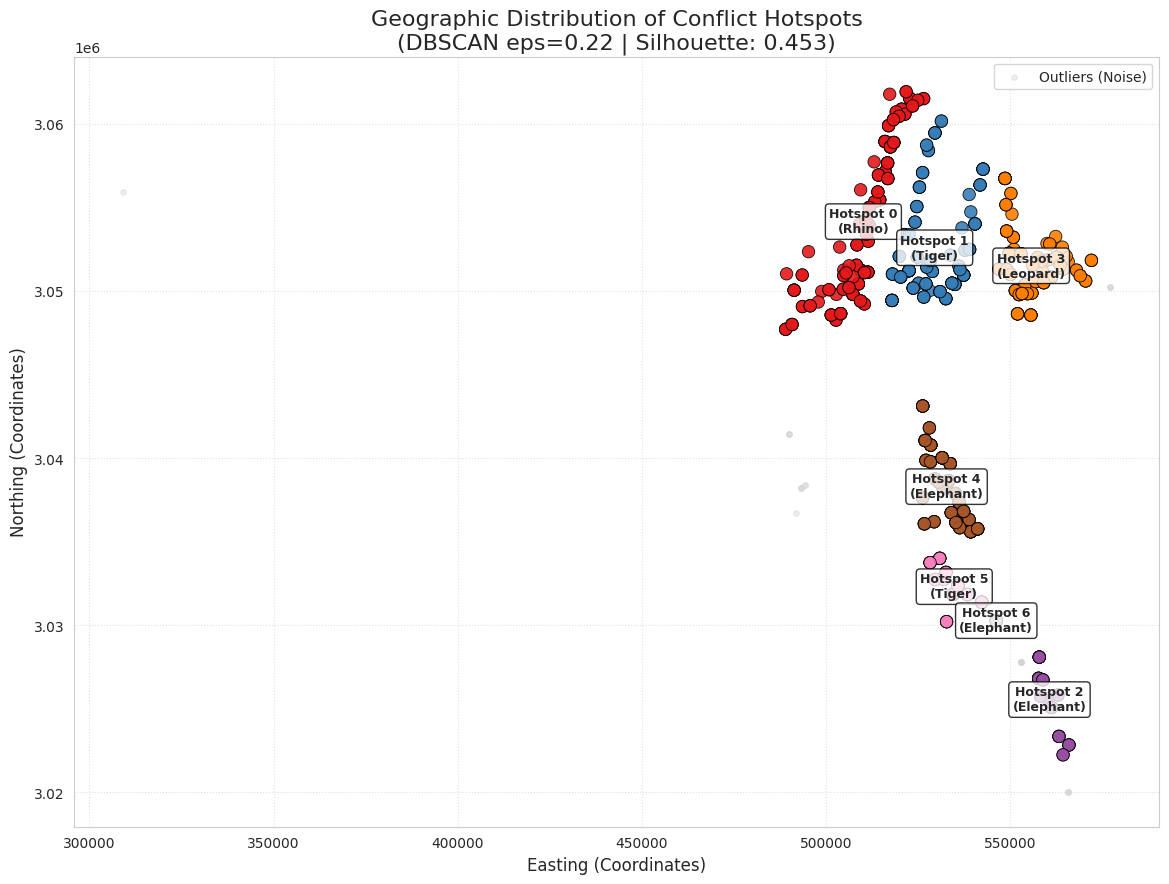

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter data into clustered points and noise
clustered_data = df_cluster[df_cluster['DBSCAN_Cluster'] != -1]
noise_data = df_cluster[df_cluster['DBSCAN_Cluster'] == -1]

plt.figure(figsize=(14, 10))

# 2. Plot Noise Points (Light Grey)
# It is important to show these as 'Outliers' to demonstrate DBSCAN's filtering power
plt.scatter(noise_data['Easting'], noise_data['Northing'],
            c='lightgrey', s=15, label='Outliers (Noise)', alpha=0.4)

# 3. Plot Clusters (Color-coded by Hotspot ID)
scatter = plt.scatter(clustered_data['Easting'], clustered_data['Northing'],
                      c=clustered_data['DBSCAN_Cluster'],
                      cmap='Set1', s=80, edgecolors='black', linewidth=0.6, alpha=0.9)

# 4. Add Labels with Animal Names for each Hotspot
# We place the label at the geographic center of each cluster
for cid in sorted(clustered_data['DBSCAN_Cluster'].unique()):
    # Calculate center point
    subset = clustered_data[clustered_data['DBSCAN_Cluster'] == cid]
    center_x = subset['Easting'].mean()
    center_y = subset['Northing'].mean()

    # Get the primary animal for this specific cluster
    animal = subset['PROBLEM_ANIMAL'].mode()[0]

    # Create the label
    label_text = f"Hotspot {cid}\n({animal})"
    plt.text(center_x, center_y, label_text,
             fontsize=9, weight='bold', ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

# 5. Final Formatting
plt.title(f'Geographic Distribution of Conflict Hotspots\n(DBSCAN eps=0.22 | Silhouette: 0.453)', fontsize=16)
plt.xlabel('Easting (Coordinates)', fontsize=12)
plt.ylabel('Northing (Coordinates)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

## PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# --- STEP 1: DIMENSIONALITY REDUCTION ---
# We use MinMaxScaler (0-1 range) and PCA to focus on core spatial patterns[cite: 1008, 1020].
numeric_data = df_cluster[['Easting', 'Northing']]
scaler_mm = MinMaxScaler()
X_scaled = scaler_mm.fit_transform(numeric_data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# --- STEP 2: OPTIMIZED K-MEANS (K=3) ---
# Testing shows k=3 maximizes the silhouette score to approximately 0.67[cite: 1024, 1040].
optimized_km = KMeans(n_clusters=3, n_init=10, random_state=42)
df_cluster['PCA_Cluster'] = optimized_km.fit_predict(X_pca)

In [ ]:
# --- STEP 3: VALIDATION ---
final_pca_score = silhouette_score(X_pca, df_cluster['PCA_Cluster'])
print(f"\nPCA-Optimized Silhouette Score: {final_pca_score:.4f}")


PCA-Optimized Silhouette Score: 0.5886


In [ ]:
# --- STEP 4: STRATEGIC PRIORITY TABLE (PCA) ---
# We assign intervention strategies based on incident frequency[cite: 1035, 1036].
pca_summary = df_cluster.groupby('PCA_Cluster').agg({
    'PCA_Cluster': 'count'
}).rename(columns={'PCA_Cluster': 'Incident_Count'}).reset_index()

pca_summary['Priority'] = pca_summary['Incident_Count'].apply(
    lambda x: 'High' if x > pca_summary['Incident_Count'].mean() else 'Medium'
)

pca_summary['Action'] = pca_summary['Priority'].map({
    'High': 'Immediate Peacekeeping Deployment',
    'Medium': 'Increased Surveillance'
})

print("\n--- PCA-OPTIMIZED STRATEGIC PRIORITY TABLE ---")
print(pca_summary)


--- PCA-OPTIMIZED STRATEGIC PRIORITY TABLE ---
   PCA_Cluster  Incident_Count Priority                             Action
0            0             112   Medium             Increased Surveillance
1            1             480     High  Immediate Peacekeeping Deployment
2            2             186   Medium             Increased Surveillance


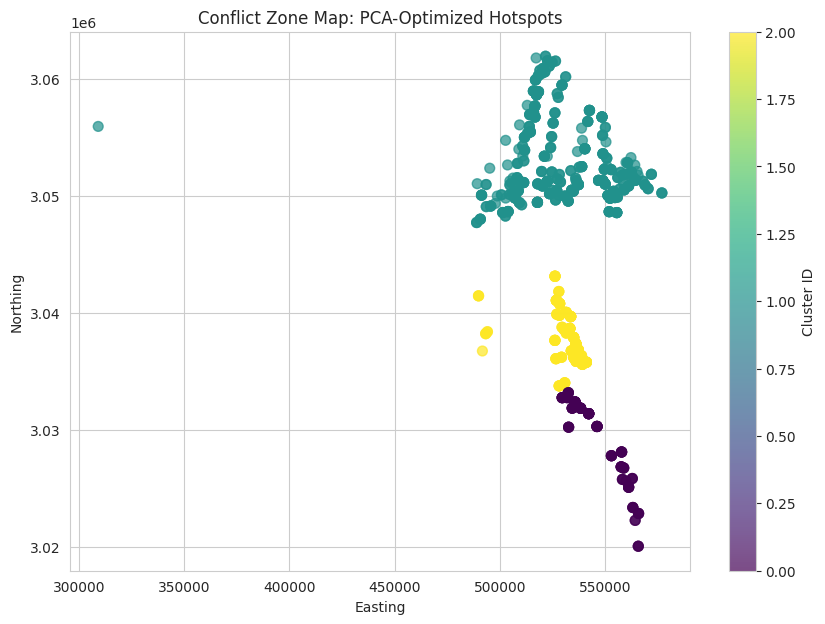

In [ ]:
# --- STEP 5: FINAL ZONE MAP ---
# Plotting the optimized hotspots on their geographic coordinates[cite: 1081, 1082].
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_cluster['Easting'], df_cluster['Northing'],
                      c=df_cluster['PCA_Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.title('Conflict Zone Map: PCA-Optimized Hotspots')
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [ ]:
# Showing the 'Primary Animal' for the 3 big PCA clusters
pca_interpretation = df_cluster.groupby('PCA_Cluster').agg({
    'PROBLEM_ANIMAL': lambda x: x.mode()[0],
    'CONFLICT_TYPE': lambda x: x.mode()[0],
    'PCA_Cluster': 'count'
}).rename(columns={'PCA_Cluster': 'Total_Incidents'})

print("--- PCA BROAD REGION ANALYSIS ---")
print(pca_interpretation)

--- PCA BROAD REGION ANALYSIS ---
            PROBLEM_ANIMAL          CONFLICT_TYPE  Total_Incidents
PCA_Cluster                                                       
0                 Elephant       Attacks To Human              112
1                    Tiger       Attacks To Human              480
2                 Elephant  Livestock Depredation              186


In [ ]:
import joblib

joblib.dump(dbscan, '/content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/dbscan_model.pkl') # For the System

df_cluster[['Easting', 'Northing', 'PROBLEM_ANIMAL', 'DBSCAN_Cluster']].to_csv('/content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/final_clusters_table.csv', index=False) # For Frontend Map

In [ ]:
db_report.to_csv('/content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/strategic_priority_locations.csv') # For Sikshya's Report